# S2D Initialization Drift Diagnostics — Refactored Pipeline

Reproducible pipeline for diagnosing initialization consistency and model drift
in E3SM S2D hindcasts.

**Five-layer architecture**

| Layer | Module | Responsibility |
|---|---|---|
| 1–9 | `drift` (config + core) | Dataclasses, calendar, diagnostics, bootstrap — no I/O |
| 10–12 | `drift` (I/O sections) | Unit conversions, ESP-Lab cache reader, pipeline runner |
| 4 | Notebook (this file) | Thin orchestration |
| 5 | `tests/test_drift_core.py` | Offline smoke test |

**Drift diagnostics defined here**

* **B(τ)** = absolute forecast bias
* **D(τ)** = B(τ) − B(τ₀) = adjustment relative to baseline lead
* **ΔD(τ)** = D_test − D_ref = paired method difference

Skill (RMSE, ACC, spread, spread/RMSE) is computed separately.


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import re
import itertools as _itertools
from pathlib import Path
from typing import Dict

import cftime
import dask
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from esp_lab import data_access_e3sm as data_access
from esp_lab import data_access_obs as obs_access
from esp_lab import stats
from esp_lab.utils import spatial_utils as spatial
from esp_lab.utils import calendar_utils as cal
from esp_lab.utils import mov_utils as mov
from esp_lab.paths import (
    S2D_DIAG_ROOT,
    E3SMLE_DIAG_DIR,
    CESM_SMYLE_DIAG_DIR,
    NMME_DIAG_DIR,
    MODES_VARIABILITY_DIAG_DIR,
    figure_output_dir,
    multimodel_diagnostic_dir,
)
from esp_lab.utils.dask_utils import DaskConfig, get_cluster_client, close_cluster
from esp_lab.diagnostics import S2DDiagnostics, S2DConfig

# New drift pipeline modules
from esp_lab.diagnostics import (
    ExperimentSpec,
    VariableSpec,
    DriftConfig,
    CaseArray,
    absolute_bias,
    adjustment,
    paired_difference,
    bootstrap_paired_ci,
    build_obs_lookup,
    compute_skill,
    lead_to_cal_month,
    valid_year_month,
    window_summary,
    write_manifest,
    build_obs_regional,
    cache_to_case_array,
    open_regional_cache,
    regional_cache_path,
    run_pipeline,
)

print("xarray:", xr.__version__)
print("dask:", dask.__version__)


xarray: 2026.4.0
dask: 2026.3.0


## Dask Setup

In [ ]:
machine_env = os.environ.get("CLUSTER_TYPE", "local")

dask_cfg = DaskConfig(
    cluster_type=machine_env,
    workers=30,
    cores=4,
    memory="16GB",
    walltime="02:00:00",
    queue=None,
    project=None,
)

cluster, client = get_cluster_client(dask_cfg)
print(client)



!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
This can easily exceed memory/CPU limits and crash your Jupyter kernel.
We highly recommend launching Jupyter on an Exclusive Perlmutter Compute Node.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
<Client: 'tcp://127.0.0.1:40123' processes=4 threads=4, memory=14.90 GiB>


2026-08-08 09:10:52,472 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('moment_combine-partial-1548306100fdb68285907b9c49cb5e6e', 1, 1, 0) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: Alias(('moment_combine-partial-1548306100fdb68285907b9c49cb5e6e', 1, 1, 0)->('getitem-moment_chunk-open_dataset-transpose-moment_combine-partial-1548306100fdb68285907b9c49cb5e6e', 1, 1, 0))
new run_spec: Alias(('moment_combine-partial-1548306100fdb68285907b9c49cb5e6e', 1, 1, 0)->('moment_chunk-moment_combine-partial-1548306100fdb68285907b9c49cb5e6e', 1, 1, 0))
old dependencies: {('getitem-moment_chunk-open_datase

## User Configuration

**All** experiment and variable parameters are defined here.
Changes to case names, variables, or regions should not require edits
to any cell below this one.


In [3]:
# =========================================================
# STEP 1 — Define experiments explicitly.
# To run Reanalysis–DART: update labels and case_prefix below.
# =========================================================
EXPERIMENTS: Dict[str, ExperimentSpec] = {
    "JRA55_FOSIRL": ExperimentSpec(
        label="JRA55_FOSIRL",
        case_prefix="WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL",
        init_description="JRA55-forced FOSIRL ocean initialization",
    ),
    "Reanalysis": ExperimentSpec(
        label="Reanalysis",
        case_prefix="WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce",
        init_description="Brute-force reanalysis initialization",
    ),
}

# =========================================================
# STEP 2 — Choose the primary variable.
# =========================================================
from esp_lab.diagnostics.drift import (
    convert_kelvin_to_celsius_if_needed,
    convert_precip_mps_to_mmday,
    convert_pa_to_hpa,
    no_conversion,
)

VARIABLE_CONFIG: Dict[str, VariableSpec] = {
    "SST": VariableSpec(
        native_field="TS", plot_name="SST", plot_units="degC",
        obs_product="HadISST2", obs_var="sst", obs_yrs=1979, obs_yre=2022,
        mask="ocean",
        model_convert=convert_kelvin_to_celsius_if_needed,
        obs_convert=convert_kelvin_to_celsius_if_needed,
    ),
    "TREFHT": VariableSpec(
        native_field="TREFHT", plot_name="2-m air temperature", plot_units="degC",
        obs_product="ERA5", obs_var="tas", obs_yrs=1979, obs_yre=2019,
        mask="none",
        model_convert=convert_kelvin_to_celsius_if_needed,
        obs_convert=convert_kelvin_to_celsius_if_needed,
    ),
    "PRECT": VariableSpec(
        native_field="PRECT", plot_name="precipitation", plot_units="mm/day",
        obs_product="GPCP_v2.3", obs_var="pr", obs_yrs=1979, obs_yre=2017,
        mask="none",
        model_convert=convert_precip_mps_to_mmday,
        obs_convert=no_conversion,
    ),
    "PSL": VariableSpec(
        native_field="PSL", plot_name="sea-level pressure", plot_units="hPa",
        obs_product="ERA5", obs_var="psl", obs_yrs=1979, obs_yre=2019,
        mask="none",
        model_convert=convert_pa_to_hpa,
        obs_convert=convert_pa_to_hpa,
    ),
}

primary_field = "PRECT"   # ← change this to analyse a different variable
var_spec = VARIABLE_CONFIG[primary_field]

# =========================================================
# STEP 3 — Analysis configuration.
# =========================================================
DRIFT_CFG = DriftConfig(
    init_years    = [1980, 1981, 1982, 1983, 1984, 1985, 1986],
    leads         = list(range(1, 25)),   # 24 monthly leads
    members       = [f"EN{i:02d}" for i in range(10)],
    init_months   = [5, 11],             # May and November
    baseline_lead = 1,                   # D(τ₀) = 0 here
    n_bootstrap   = 1000,
    bootstrap_seed= 42,
    window_defs   = {
        "early_adj":    (1, 3),
        "first_season": (1, 6),
        "first_year":   (1, 12),
        "second_year":  (13, 24),
    },
    freq_tag      = "mon",
    region        = [-170.0, -120.0, -5.0, 5.0],
    region_name   = "Nino3.4",
)

# =========================================================
# STEP 4 — Paths and output directories.
# =========================================================
DIAG_ROOT     = S2D_DIAG_ROOT
data_dir      = "/global/cfs/cdirs/e3sm/S2S2D/post_process"
obs_dir       = "/global/cfs/cdirs/e3sm/e3sm_diags/obs_for_e3sm_diags/time-series"
outdir        = Path(DIAG_ROOT)
FIGURE_OUTDIR = figure_output_dir("leadtime_drift", "atm", "regional")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

summary_table_outdir = multimodel_diagnostic_dir("leadtime_drift", "atm", "regional", "summary_tables")

# Misc display settings (do not affect calculations)
force_rewrite            = False
persist_intermediate     = False
load_regional_series     = True
realm = "atm"; grid = "180x360_aave"; freq = "monthly"
ts_split = "2yr"; engine = "netcdf4"; chunks_open = {}
reg_chunk = {"Y": 1, "L": DRIFT_CFG.n_leads, "M": 2}
require_all_members  = True
verify_field_name    = True
verify_coverage      = True

# =========================================================
# Derived display constants (do not edit)
# =========================================================
exp_labels   = list(EXPERIMENTS.keys())
_base_colors = ["royalblue", "firebrick", "forestgreen", "darkorange",
                "mediumpurple", "saddlebrown", "deeppink", "teal"]
exp_colors   = {lbl: col for lbl, col in zip(exp_labels, _itertools.cycle(_base_colors))}
experiment_markers = {"JRA55_FOSIRL": "o", "Reanalysis": "s"}
month_names  = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
init_labels  = {2:"FEB init", 5:"MAY init", 8:"AUG init", 11:"NOV init"}
spinup_lead_months = (0, 2)
spinup_span  = (spinup_lead_months[0] - 0.5, spinup_lead_months[1] + 0.5)
spinup_label = "Spin-up window"
lead_label_every = 3
comparison_scatter_label_leads = [1, 4, 7, 13, 19, 24]

def _safe_token(v): return re.sub(r"[^A-Za-z0-9]+", "_", str(v)).strip("_").lower()
def figure_filename(*parts, ext="png"):
    clean = ["fig"] + [_safe_token(p) for p in parts if str(p).strip()]
    return "_".join(clean) + f".{ext.lstrip('.').lower()}"

year_label = f"{min(DRIFT_CFG.init_years)}_{max(DRIFT_CFG.init_years)}"
analysis_prefix = "_".join(
    _safe_token(part) for part in [
        primary_field, DRIFT_CFG.region_name, DRIFT_CFG.freq_tag,
        "_vs_".join(exp_labels), year_label,
    ]
)

print("Experiments     :", exp_labels)
print("Primary field   :", primary_field, "/", var_spec.native_field)
print("Region          :", DRIFT_CFG.region_name, DRIFT_CFG.region)
print("Init years      :", DRIFT_CFG.init_years)
print("Init months     :", DRIFT_CFG.init_months)
print("Leads           :", DRIFT_CFG.leads)
print("Baseline lead   :", DRIFT_CFG.baseline_lead)
print("Bootstrap n     :", DRIFT_CFG.n_bootstrap)


Experiments     : ['JRA55_FOSIRL', 'Reanalysis']
Primary field   : PRECT / PRECT
Region          : Nino3.4 [-170.0, -120.0, -5.0, 5.0]
Init years      : [1980, 1981, 1982, 1983, 1984, 1985, 1986]
Init months     : [5, 11]
Leads           : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Baseline lead   : 1
Bootstrap n     : 1000


## Figure Style

In [4]:
fontz = 14
FS = {
    "suptitle"   : int(round(fontz * 1.1)),
    "title"      : int(round(fontz * 1.0)),
    "label"      : int(round(fontz * 0.95)),
    "tick"       : int(round(fontz * 0.95)),
    "legend"     : int(round(fontz * 0.90)),
    "legend_title": int(round(fontz * 0.95)),
    "colorbar"   : int(round(fontz * 0.95)),
    "table"      : int(round(fontz * 0.90)),
}
FIG = {
    "dpi": 220,
    "line_width": 2.0, "thin_line_width": 0.8, "marker_size": 5.0,
    "scatter_size": 42, "scatter_edge_width": 0.7,
    "grid_alpha": 0.4, "band_alpha": 0.2, "line_alpha": 0.55,
    "single_case_figsize": (10.5, 8.2),
    "diagnostic_col_width": 7.0, "diagnostic_fig_height": 11.0,
    "season_col_width": 7.0, "season_fig_height": 6.0,
    "summary_min_width": 12.0, "summary_lead_width": 0.48,
    "summary_row_height": 1.0, "summary_extra_height": 3.5,
}
plt.rcParams.update({
    "font.size": FS["label"], "axes.titlesize": FS["title"],
    "axes.labelsize": FS["label"], "xtick.labelsize": FS["tick"],
    "ytick.labelsize": FS["tick"], "legend.fontsize": FS["legend"],
    "figure.titlesize": FS["suptitle"],
})

def apply_axis_style(ax):
    ax.grid(True, alpha=FIG["grid_alpha"])
    ax.tick_params(labelsize=FS["tick"])

def format_lead_time_axis(ax, leads, init_month, show_labels=True, label_every=None):
    if label_every is None:
        label_every = lead_label_every
    lead_months = np.asarray(leads) - 1
    if len(lead_months) == 0:
        return lead_months
    tick_idx = list(range(0, len(lead_months), label_every))
    if tick_idx[-1] != len(lead_months) - 1:
        tick_idx.append(len(lead_months) - 1)
    major_ticks = lead_months[tick_idx]
    major_labels = [
        f"L{int(lead_months[i])}\n{month_names[lead_to_cal_month(init_month, leads[i]) - 1]}"
        for i in tick_idx
    ]
    ax.set_xlim(float(np.nanmin(lead_months)) - 0.75, float(np.nanmax(lead_months)) + 0.75)
    ax.set_xticks(major_ticks)
    ax.set_xticks(lead_months, minor=True)
    if show_labels:
        ax.set_xticklabels(major_labels, fontsize=FS["tick"])
    else:
        ax.tick_params(axis="x", labelbottom=False)
    ax.grid(which="minor", axis="x", alpha=0.16, linewidth=FIG["thin_line_width"])
    return lead_months


## Load / Compute Regional Hindcast Caches

Each experiment is opened from its regional-index cache (written by `S2DDiagnostics`).
The result is validated by `CaseArray` to enforce the strict `(Y, M, L)` data contract.


In [5]:
%%time

def _cache_path(exp_label, init_month, freq_tag):
    return regional_cache_path(
        outdir, exp_label, init_month, freq_tag,
        primary_field, DRIFT_CFG.region_name,
    )

case_arrays: Dict[str, Dict[int, CaseArray]] = {}

for exp_label, exp_spec in EXPERIMENTS.items():
    case_arrays[exp_label] = {}
    print("\n" + "=" * 70)
    print(f"Experiment: {exp_label}  |  case_prefix: {exp_spec.case_prefix}")

    needed = [
        _cache_path(exp_label, m, tag)
        for m in DRIFT_CFG.init_months
        for tag in (DRIFT_CFG.freq_tag,)
    ]
    use_cache = all(p.exists() for p in needed) and not force_rewrite

    if not use_cache:
        print("[RUN] computing regional indices via S2DDiagnostics ...")
        exp_dir = _cache_path(
            exp_label, DRIFT_CFG.init_months[0], DRIFT_CFG.freq_tag
        ).parent
        exp_dir.mkdir(parents=True, exist_ok=True)
        cfg_exp = S2DConfig(
            case_prefix=exp_spec.case_prefix,
            outdir=str(exp_dir),
            field=var_spec.native_field,
            data_dir=data_dir,
            members=DRIFT_CFG.members,
            nlead=DRIFT_CFG.n_leads,
            init_months=DRIFT_CFG.init_months,
            init_years={m: DRIFT_CFG.init_years for m in DRIFT_CFG.init_months},
            region=DRIFT_CFG.region,
            region_name=DRIFT_CFG.region_name,
            climy0=min(DRIFT_CFG.init_years),
            climy1=max(DRIFT_CFG.init_years),
            force_rewrite=force_rewrite,
            realm=realm, grid=grid, freq=freq, ts_split=ts_split,
            engine=engine, chunks=chunks_open,
            require_all_members=require_all_members,
            verify_field_name=verify_field_name,
            verify_coverage=verify_coverage,
            persist_intermediate=persist_intermediate,
            load_regional_series=load_regional_series,
        )
        diag_exp = S2DDiagnostics(
            cfg=cfg_exp, data_access=data_access,
            obs_access=obs_access, stats=stats, spatial=spatial, cal=cal,
        )
        results = diag_exp.run()

        for init_month in DRIFT_CFG.init_months:
            for tag in ("mon", "seas"):
                da = results[init_month][tag].chunk(reg_chunk)
                da = var_spec.model_convert(da).rename("regional_index")
                da.attrs.update(
                    experiment=exp_label, case_prefix=exp_spec.case_prefix,
                    region=DRIFT_CFG.region_name, lonlat=str(DRIFT_CFG.region),
                    field=primary_field, native_field=var_spec.native_field,
                    units=var_spec.plot_units, frequency=tag,
                )
                path = _cache_path(exp_label, init_month, tag)
                if path.exists():
                    path.unlink()
                da.to_netcdf(path, encoding={"regional_index": {"zlib": True, "complevel": 1}})
    else:
        print("[READ] using cached regional files")

    # Load, convert units, validate via CaseArray
    for init_month in DRIFT_CFG.init_months:
        path = _cache_path(exp_label, init_month, DRIFT_CFG.freq_tag)
        da_raw = open_regional_cache(
            path, var_spec, reg_chunk=reg_chunk,
            expected_attrs={
                "experiment": exp_label,
                "case_prefix": exp_spec.case_prefix,
                "region": DRIFT_CFG.region_name,
                "lonlat": str(DRIFT_CFG.region),
                "field": primary_field,
                "frequency": DRIFT_CFG.freq_tag,
            },
        )
        case_arrays[exp_label][init_month] = cache_to_case_array(
            da_raw, exp_label, DRIFT_CFG
        )
        ca = case_arrays[exp_label][init_month]
        print(f"  init_month={init_month}: {ca}")

print("\nAll CaseArrays loaded and validated.")



Experiment: JRA55_FOSIRL  |  case_prefix: WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL
[READ] using cached regional files


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/drift.py:927: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_dataarray(path, chunks=reg_chunk or {})
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/drift.py:927: UserWarning: The specified chunks separate the stored chunks along dimension "M" starting at index 2. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_dataarray(path, chunks=reg_chunk or {})
<timed exec>:86: RuntimeWarning: Experiment 'JRA55_FOSIRL': cache is missing requested initialization years [1984, 1985, 1986]; available requested years are [1980, 1981, 1982, 1983]. Comparative diagnostics will use the common-year intersection.


  init_month=5: CaseArray('JRA55_FOSIRL') Y=[np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983)] M=10 L=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
  init_month=11: CaseArray('JRA55_FOSIRL') Y=[np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983)] M=10 L=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]

Experiment: Reanalysis  |  case_prefix: WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce
[READ] using cached re

/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/drift.py:927: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_dataarray(path, chunks=reg_chunk or {})
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/drift.py:927: UserWarning: The specified chunks separate the stored chunks along dimension "M" starting at index 2. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_dataarray(path, chunks=reg_chunk or {})
<timed exec>:86: RuntimeWarning: Experiment 'JRA55_FOSIRL': cache is missing requested initialization years [1984, 1985, 1986]; available requested years are [1980, 1981, 1982, 1983]. Comparative diagnostics will use the common-year intersection.
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/drift.py:927: UserWarning: The specified chunks separate the stored chunks along dimension "Y" st

  init_month=5: CaseArray('Reanalysis') Y=[np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986)] M=10 L=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
  init_month=11: CaseArray('Reanalysis') Y=[np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986)] M=10 L=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]

All CaseArrays loa

/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/drift.py:927: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_dataarray(path, chunks=reg_chunk or {})
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/drift.py:927: UserWarning: The specified chunks separate the stored chunks along dimension "M" starting at index 2. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_dataarray(path, chunks=reg_chunk or {})


## Load Observed Reference Series

In [6]:
%%time

obs_series = build_obs_regional(
    obs_access=obs_access,
    var_spec=var_spec,
    drift_cfg=DRIFT_CFG,
    obs_dir=obs_dir,
    spatial=spatial,
)

if obs_series is None:
    raise ValueError(
        f"No observation product configured for {primary_field}. "
        "Choose a field with obs_product set in VARIABLE_CONFIG."
    )

print("Obs series:", obs_series)


[OBS] Mapping field 'PRECT' -> 'pr'
[OBS] Loading: /global/cfs/cdirs/e3sm/diagnostics/observations/Atm/time-series/GPCP_v2.3/PRECT_197901_201712.nc
[OBS] File matched field 'PRECT' for requested field 'pr'
Obs series: <xarray.DataArray 'obs_regional_index' (time: 120)> Size: 480B
array([ 1.2897571 ,  1.3449748 ,  2.708536  ,  3.1274285 ,  2.896672  ,
        2.4285357 ,  1.5525928 ,  1.0312446 ,  0.6588669 ,  0.8791572 ,
        0.9550349 ,  1.3824942 ,  1.4872212 ,  2.1481647 ,  3.4927065 ,
        3.4119186 ,  2.0791361 ,  2.1679718 ,  1.3716178 ,  0.8012215 ,
        0.71702063,  0.831433  ,  0.8313007 ,  1.3295965 ,  1.2707162 ,
        2.0118709 ,  3.282527  ,  3.5809696 ,  2.0988815 ,  2.6717765 ,
        1.9203188 ,  1.9046696 ,  1.8976058 ,  3.54378   ,  7.223536  ,
       11.417217  , 11.8808    , 10.400202  ,  7.599784  ,  7.7053213 ,
        8.147801  ,  5.9189696 ,  2.38656   ,  1.0080644 ,  1.0262777 ,
        0.7871839 ,  0.9495673 ,  0.87483656,  0.95121723,  1.3812209 ,

## Drift and Skill Diagnostics

For each experiment and initialization month, compute:

* **B(τ)** = absolute bias (ensemble mean vs obs climatology over analysis window)
* **D(τ)** = B(τ) − B(τ₀) = adjustment from baseline lead (zero at τ₀)
* Skill: RMSE, ACC, ensemble spread, spread/RMSE

For the paired comparison (exactly 2 experiments), additionally compute:

* **ΔD(τ)** = D_test − D_ref = paired method difference
* **95 % bootstrap CI** on ΔD, resampling start years

> ℹ️ **Adjustment vs. shock** — for monthly data, D(τ) measures *early adjustment*
> (leads 1–3) or *first-season adjustment* (leads 1–6).  A true *shock* analysis
> requires daily or sub-daily restart output and a separate companion workflow.


In [7]:
%%time

pipeline_results = run_pipeline(
    experiment_specs=EXPERIMENTS,
    var_spec=var_spec,
    drift_cfg=DRIFT_CFG,
    case_arrays=case_arrays,
    obs_series=obs_series,
    outdir=summary_table_outdir,
    prefix=analysis_prefix,
    write_outputs=True,
)

# Convenience aliases used by the plotting cells below
bias_by_exp        = pipeline_results["bias"]          # {label: {init_month: DataArray}}
adj_by_exp         = pipeline_results["adjustment"]     # {label: {init_month: DataArray}}
skill_by_exp       = pipeline_results["skill"]          # {label: {init_month: dict}}
paired_diff        = pipeline_results["paired_diff"]    # {init_month: DataArray}
ci_lower           = pipeline_results["ci_lower"]
ci_upper           = pipeline_results["ci_upper"]
window_tables      = pipeline_results["window_tables"]  # list of DataFrames

print("\n=== Window-level summary ===")
summary_all = pd.concat(window_tables, ignore_index=True)
display(summary_all)



=== Window-level summary ===


,experiment,init_month,window,lead_first,lead_last,n_leads,mean_bias,mean_abs_adj,adj_slope,mean_rmse,mean_acc,mean_spread,mean_spread_rmse,baseline_lead,n_years,sample_years
0,JRA55_FOSIRL,5,early_adj,1,3,3,1.257652,2.347664,-2.091976,2.094184,0.801190,0.525881,0.385478,1,4,"1980,1981,1982,1983"
1,JRA55_FOSIRL,5,first_season,1,6,6,0.131356,3.473960,-0.845056,1.651951,0.703022,0.307246,0.236993,1,4,"1980,1981,1982,1983"
2,JRA55_FOSIRL,5,first_year,1,12,12,-1.613298,5.218614,-0.565036,3.162983,0.692978,0.292478,0.150731,1,4,"1980,1981,1982,1983"
3,JRA55_FOSIRL,5,second_year,13,24,12,-2.274234,5.879550,-0.102960,3.132267,0.546581,0.300554,0.102236,1,4,"1980,1981,1982,1983"
4,Reanalysis,5,early_adj,1,3,3,0.857915,1.412907,-1.234364,1.315961,0.982882,0.371647,0.460299,1,4,"1980,1981,1982,1983"
5,Reanalysis,5,first_season,1,6,6,-0.016929,2.287751,-0.623107,1.214584,0.769519,0.245524,0.294054,1,4,"1980,1981,1982,1983"
6,Reanalysis,5,first_year,1,12,12,-1.035485,3.306307,-0.298843,2.401968,0.639373,0.549506,0.307804,1,4,"1980,1981,1982,1983"
7,Reanalysis,5,second_year,13,24,12,-1.362278,3.633100,-0.130947,2.225299,0.795136,1.065641,0.492780,1,4,"1980,1981,1982,1983"
8,JRA55_FOSIRL,11,early_adj,1,3,3,-0.305370,0.196502,-0.141208,0.652578,0.999260,0.382638,0.590942,1,4,"1980,1981,1982,1983"
9,JRA55_FOSIRL,11,first_season,1,6,6,-0.994394,0.885526,-0.432370,1.229808,0.996610,0.657834,0.560511,1,4,"1980,1981,1982,1983"


CPU times: user 11.2 s, sys: 1.73 s, total: 13 s
Wall time: 21.2 s


## Plot: Adjustment (Drift) Comparison

/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_prect_nino3_4_mon_jra55_fosirl_vs_reanalysis_1980_1986_drift_comparison_init05.png


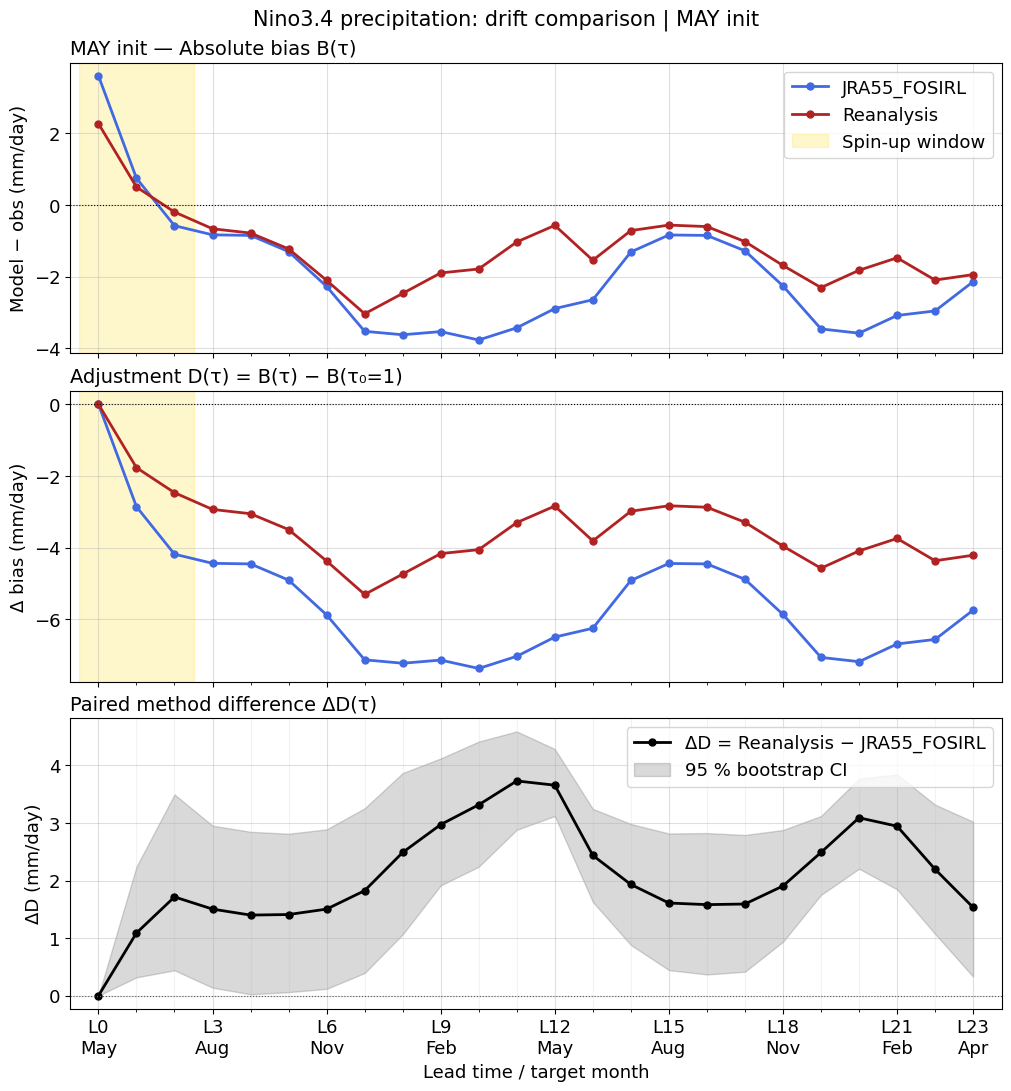

/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_prect_nino3_4_mon_jra55_fosirl_vs_reanalysis_1980_1986_drift_comparison_init11.png


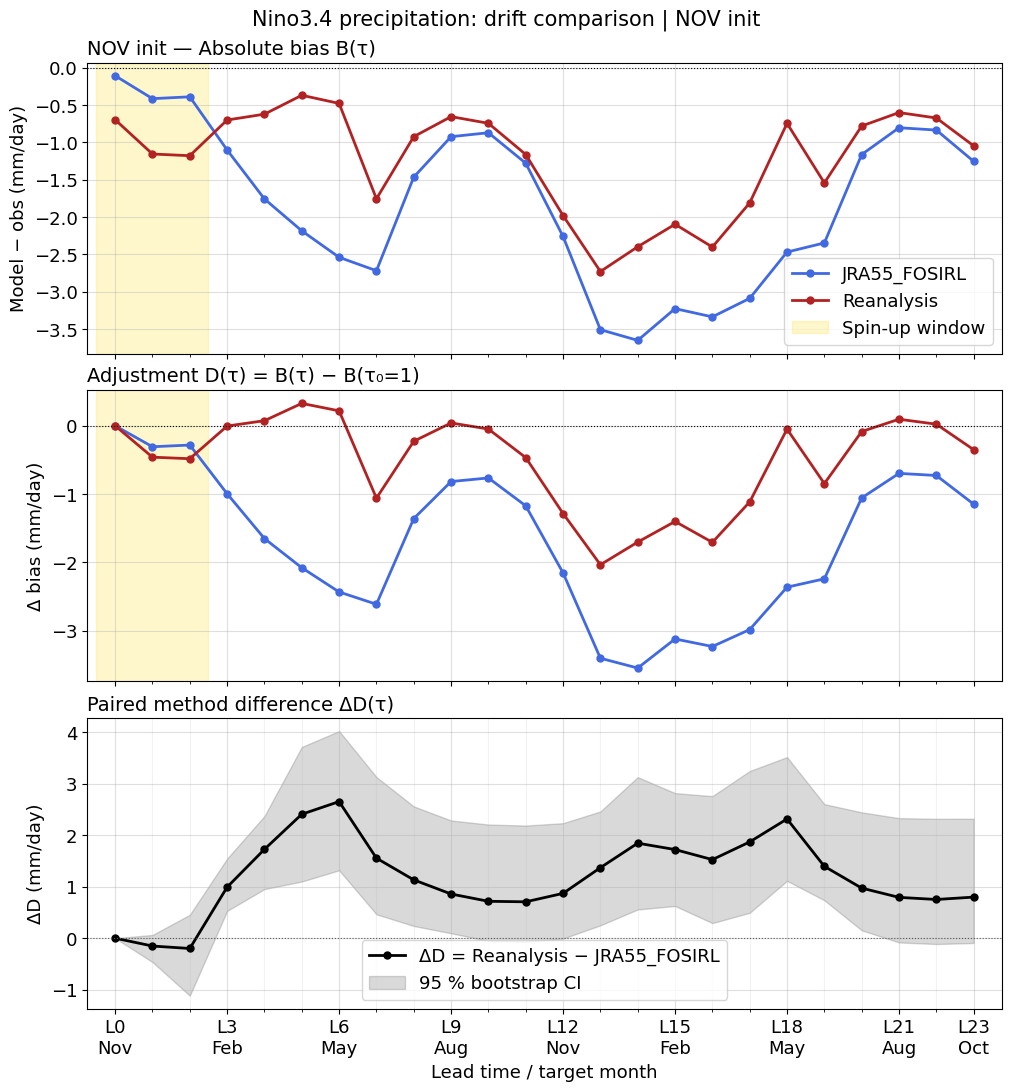

In [8]:
def plot_drift_comparison(init_month):
    """Plot B(τ), D(τ), and ΔD(τ) for a given initialization month."""
    init_label = init_labels.get(init_month, f"{init_month:02d} init")
    n_rows = 3 if len(exp_labels) == 2 else 2
    fig, axes = plt.subplots(
        n_rows, 1,
        figsize=(10, 3.6 * n_rows),
        sharex=True,
        constrained_layout=True,
    )

    for exp_label in exp_labels:
        color = exp_colors[exp_label]
        bias = bias_by_exp[exp_label][init_month]
        adj  = adj_by_exp[exp_label][init_month]
        lead_months = bias.L.values - 1

        axes[0].plot(
            lead_months, bias.values,
            marker="o", markersize=FIG["marker_size"],
            linewidth=FIG["line_width"], color=color, label=exp_label,
        )
        axes[1].plot(
            lead_months, adj.values,
            marker="o", markersize=FIG["marker_size"],
            linewidth=FIG["line_width"], color=color, label=exp_label,
        )

    for ax in axes[:2]:
        ax.axhline(0, color="black", linewidth=FIG["thin_line_width"], linestyle=":")
        ax.axvspan(spinup_span[0], spinup_span[1], color="gold",
                   alpha=FIG["band_alpha"], label=spinup_label)
        apply_axis_style(ax)

    axes[0].set_title(f"{init_label} — Absolute bias B(τ)", loc="left")
    axes[0].set_ylabel(f"Model − obs ({var_spec.plot_units})")
    axes[0].legend(fontsize=FS["legend"])

    axes[1].set_title(f"Adjustment D(τ) = B(τ) − B(τ₀={DRIFT_CFG.baseline_lead})", loc="left")
    axes[1].set_ylabel(f"Δ bias ({var_spec.plot_units})")

    # Paired difference + bootstrap CI (2-experiment case only)
    if n_rows == 3 and init_month in paired_diff:
        pd_arr = paired_diff[init_month]
        lead_months_pd = pd_arr.L.values - 1
        axes[2].plot(
            lead_months_pd, pd_arr.values,
            color="black", marker="o", markersize=FIG["marker_size"],
            linewidth=FIG["line_width"], label=f"ΔD = {exp_labels[1]} − {exp_labels[0]}",
        )
        if init_month in ci_lower:
            lo = ci_lower[init_month]
            hi = ci_upper[init_month]
            axes[2].fill_between(
                lead_months_pd, lo.values, hi.values,
                color="black", alpha=0.15, label="95 % bootstrap CI",
            )
        axes[2].axhline(0, color="0.35", linewidth=FIG["thin_line_width"], linestyle=":")
        apply_axis_style(axes[2])
        axes[2].set_title("Paired method difference ΔD(τ)", loc="left")
        axes[2].set_ylabel(f"ΔD ({var_spec.plot_units})")
        axes[2].legend(fontsize=FS["legend"])

    format_lead_time_axis(axes[-1], bias.L.values, init_month, show_labels=True)
    axes[-1].set_xlabel("Lead time / target month")
    fig.suptitle(
        f"{DRIFT_CFG.region_name} {var_spec.plot_name}: drift comparison | {init_label}",
        fontsize=FS["suptitle"],
    )

    figname = figure_filename(analysis_prefix, "drift_comparison", f"init{init_month:02d}")
    figpath = FIGURE_OUTDIR / figname
    mov.save_figure(fig, figpath, mode="", metric="drift",
                    title=f"Drift: {primary_field}", caption=DRIFT_CFG.region_name,
                    dpi=FIG["dpi"])
    print(figpath)
    plt.show()


for init_month in DRIFT_CFG.init_months:
    plot_drift_comparison(init_month)


## Plot: Skill (RMSE · ACC · Spread/RMSE)

/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_prect_nino3_4_mon_jra55_fosirl_vs_reanalysis_1980_1986_skill_init05.png


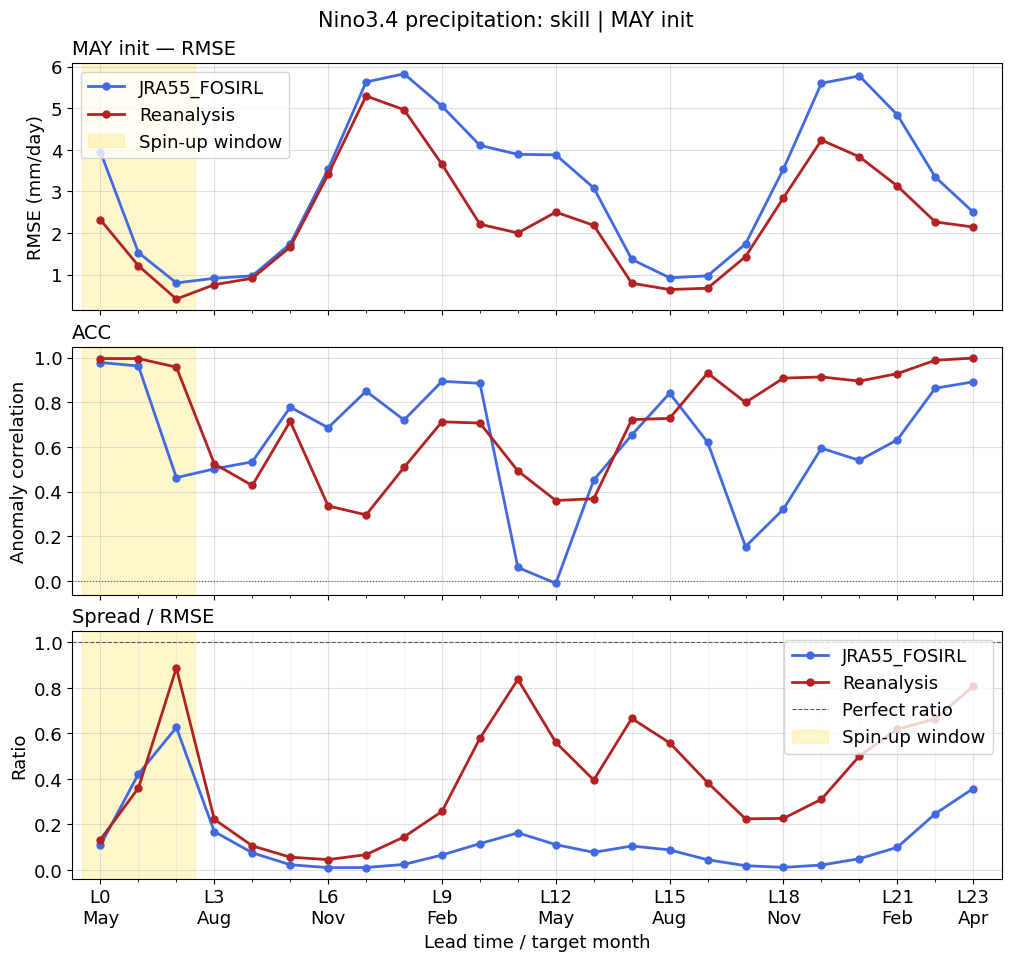

/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_prect_nino3_4_mon_jra55_fosirl_vs_reanalysis_1980_1986_skill_init11.png


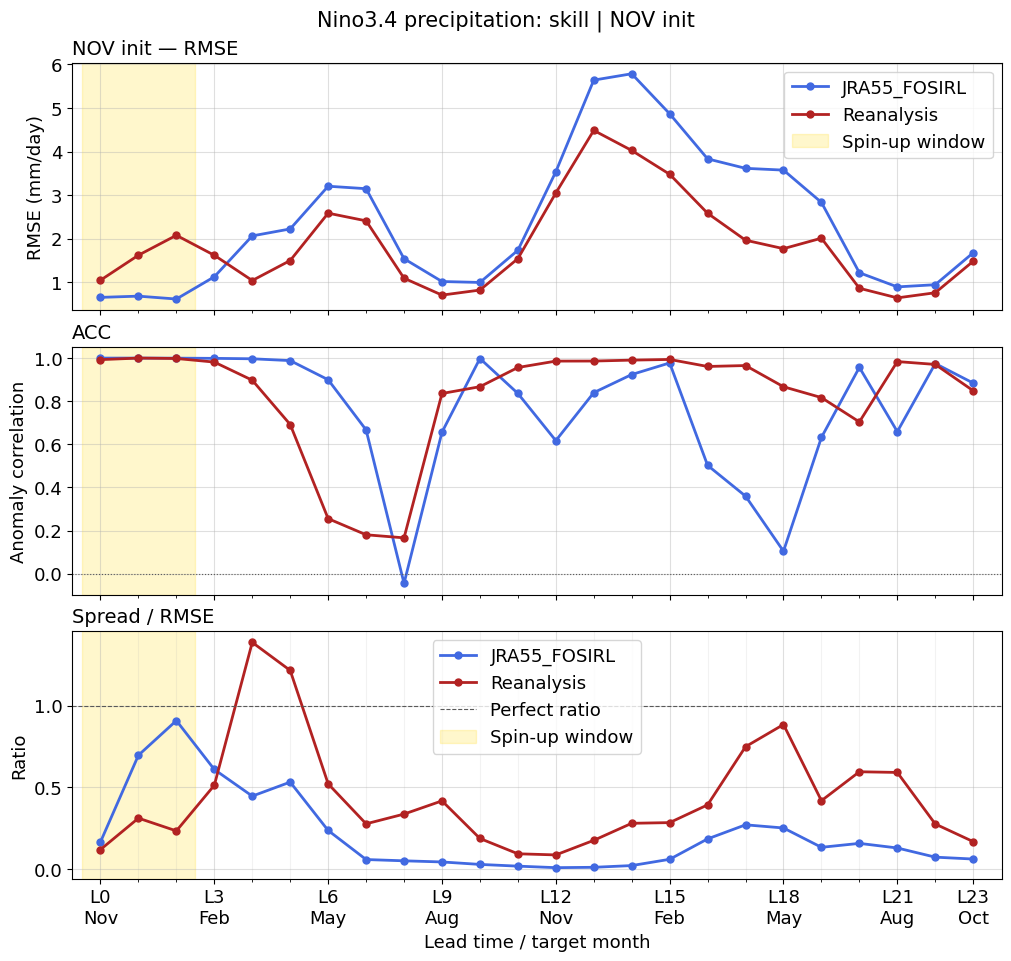

In [9]:
def plot_skill_figure(init_month):
    """Plot RMSE, ACC, and spread/RMSE separately from drift."""
    init_label = init_labels.get(init_month, f"{init_month:02d} init")
    fig, axes = plt.subplots(3, 1, figsize=(10, 9.5), sharex=True, constrained_layout=True)

    for exp_label in exp_labels:
        color = exp_colors[exp_label]
        sk = skill_by_exp[exp_label][init_month]
        leads = sk["rmse"].L.values
        lead_months = leads - 1

        axes[0].plot(lead_months, sk["rmse"].values,
                     marker="o", markersize=FIG["marker_size"],
                     linewidth=FIG["line_width"], color=color, label=exp_label)
        axes[1].plot(lead_months, sk["acc"].values,
                     marker="o", markersize=FIG["marker_size"],
                     linewidth=FIG["line_width"], color=color, label=exp_label)
        axes[2].plot(lead_months, sk["spread_rmse_ratio"].values,
                     marker="o", markersize=FIG["marker_size"],
                     linewidth=FIG["line_width"], color=color, label=exp_label)

    axes[1].axhline(0, color="0.35", linewidth=FIG["thin_line_width"], linestyle=":")
    axes[2].axhline(1, color="0.35", linewidth=FIG["thin_line_width"],
                    linestyle="--", label="Perfect ratio")

    for ax in axes:
        ax.axvspan(spinup_span[0], spinup_span[1], color="gold",
                   alpha=FIG["band_alpha"], label=spinup_label)
        apply_axis_style(ax)

    axes[0].set_title(f"{init_label} — RMSE", loc="left")
    axes[0].set_ylabel(f"RMSE ({var_spec.plot_units})")
    axes[0].legend(fontsize=FS["legend"])

    axes[1].set_title("ACC", loc="left")
    axes[1].set_ylabel("Anomaly correlation")

    axes[2].set_title("Spread / RMSE", loc="left")
    axes[2].set_ylabel("Ratio")
    axes[2].legend(fontsize=FS["legend"])

    format_lead_time_axis(axes[-1], leads, init_month, show_labels=True)
    axes[-1].set_xlabel("Lead time / target month")
    fig.suptitle(
        f"{DRIFT_CFG.region_name} {var_spec.plot_name}: skill | {init_label}",
        fontsize=FS["suptitle"],
    )

    figname = figure_filename(analysis_prefix, "skill", f"init{init_month:02d}")
    figpath = FIGURE_OUTDIR / figname
    mov.save_figure(fig, figpath, mode="", metric="skill",
                    title=f"Skill: {primary_field}", caption=DRIFT_CFG.region_name,
                    dpi=FIG["dpi"])
    print(figpath)
    plt.show()


for init_month in DRIFT_CFG.init_months:
    plot_skill_figure(init_month)


## Quick-Look Dashboard

/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_prect_nino3_4_mon_jra55_fosirl_vs_reanalysis_1980_1986_quicklook.png


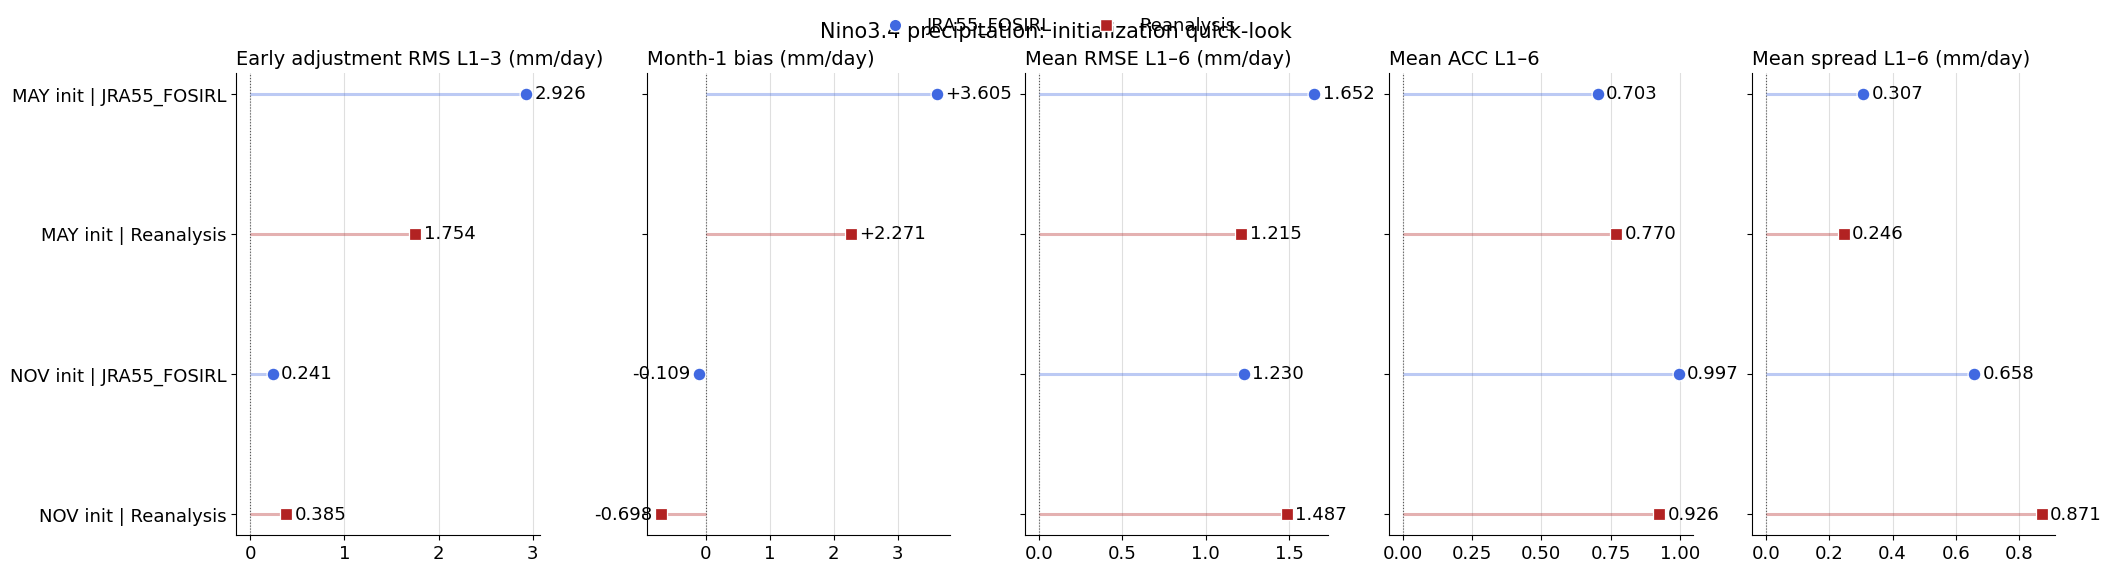

,case,experiment,init_month,init_label,early_adj_rms,month_1_bias,mean_rmse_L1_6,mean_acc_L1_6,mean_spread_L1_6
0,MAY init | JRA55_FOSIRL,JRA55_FOSIRL,5,MAY init,2.925724,3.605316,1.651951,0.703022,0.307246
1,MAY init | Reanalysis,Reanalysis,5,MAY init,1.753805,2.270822,1.214584,0.769519,0.245524
2,NOV init | JRA55_FOSIRL,JRA55_FOSIRL,11,NOV init,0.240876,-0.108868,1.229808,0.996610,0.657834
3,NOV init | Reanalysis,Reanalysis,11,NOV init,0.384684,-0.698010,1.486500,0.926348,0.870781


In [10]:
def plot_quicklook_dashboard():
    """Compact bar chart of early-adjustment, skill, and spread per case."""
    rows = []
    for init_month in DRIFT_CFG.init_months:
        for exp_label in exp_labels:
            bias = bias_by_exp[exp_label][init_month]
            sk   = skill_by_exp[exp_label][init_month]
            adj  = adj_by_exp[exp_label][init_month]
            early_leads = [L for L in bias.L.values if 1 <= L <= 3]
            season_leads = [L for L in bias.L.values if 1 <= L <= 6]
            rows.append({
                "experiment": exp_label,
                "init_month": init_month,
                "init_label": init_labels.get(init_month, f"{init_month:02d} init"),
                "early_adj_rms": float(np.sqrt((adj.sel(L=early_leads) ** 2).mean("L", skipna=True))),
                "month_1_bias": float(bias.sel(L=1)),
                "mean_rmse_L1_6": float(sk["rmse"].sel(L=season_leads).mean("L", skipna=True)),
                "mean_acc_L1_6": float(sk["acc"].sel(L=season_leads).mean("L", skipna=True)),
                "mean_spread_L1_6": float(sk["spread"].sel(L=season_leads).mean("L", skipna=True)),
            })

    df = pd.DataFrame(rows)
    df["case"] = df["init_label"] + " | " + df["experiment"]

    metric_specs = [
        ("early_adj_rms",   f"Early adjustment RMS L1–3 ({var_spec.plot_units})", "{:.3f}"),
        ("month_1_bias",    f"Month-1 bias ({var_spec.plot_units})",              "{:+.3f}"),
        ("mean_rmse_L1_6",  f"Mean RMSE L1–6 ({var_spec.plot_units})",           "{:.3f}"),
        ("mean_acc_L1_6",   "Mean ACC L1–6",                                     "{:.3f}"),
        ("mean_spread_L1_6",f"Mean spread L1–6 ({var_spec.plot_units})",         "{:.3f}"),
    ]

    case_order = [
        f"{init_labels.get(m, f'{m:02d} init')} | {lbl}"
        for m in DRIFT_CFG.init_months
        for lbl in exp_labels
    ]
    df = df.set_index("case").reindex(case_order).reset_index()
    case_y = np.arange(len(df))
    marker_cycle = ["o", "s", "^", "D", "P", "X"]
    marker_by_exp = {
        lbl: experiment_markers.get(lbl, marker_cycle[i % len(marker_cycle)])
        for i, lbl in enumerate(exp_labels)
    }

    fig, axes = plt.subplots(
        1, len(metric_specs), figsize=(4.2 * len(metric_specs), max(5.5, 0.8 * len(df))),
        sharey=True, constrained_layout=True,
    )
    for ax, (metric, title, fmt) in zip(axes, metric_specs):
        values = df[metric].astype(float).values
        ax.axvline(0, color="0.35", linewidth=FIG["thin_line_width"], linestyle=":")
        for y, (_, row) in zip(case_y, df.iterrows()):
            val = float(row[metric])
            if not np.isfinite(val):
                continue
            color = exp_colors.get(row["experiment"], "0.4")
            ax.hlines(y, 0, val, color=color, alpha=0.35, linewidth=2.2)
            ax.scatter(val, y, s=85,
                       marker=marker_by_exp.get(row["experiment"], "o"),
                       color=color, edgecolor="white", linewidth=0.9, zorder=3)
            ax.annotate(fmt.format(val), (val, y),
                        xytext=(6 if val >= 0 else -6, 0),
                        textcoords="offset points", va="center",
                        ha="left" if val >= 0 else "right", fontsize=FS["tick"])
        ax.set_title(title, loc="left", fontsize=FS["title"])
        ax.set_yticks(case_y)
        ax.set_yticklabels(df["case"].tolist(), fontsize=FS["tick"])
        ax.invert_yaxis()
        ax.grid(True, axis="x", alpha=FIG["grid_alpha"])
        ax.spines[["top", "right"]].set_visible(False)

    legend_handles = [
        Line2D([0], [0], marker=marker_by_exp.get(lbl, "o"), linestyle="",
               markerfacecolor=exp_colors.get(lbl, "0.4"),
               markeredgecolor="white", markersize=9, label=lbl)
        for lbl in exp_labels
    ]
    fig.legend(handles=legend_handles, loc="upper center", ncol=len(legend_handles),
               frameon=False, bbox_to_anchor=(0.5, 1.03))
    fig.suptitle(f"{DRIFT_CFG.region_name} {var_spec.plot_name}: initialization quick-look",
                 fontsize=FS["suptitle"])

    figname = figure_filename(analysis_prefix, "quicklook")
    figpath = FIGURE_OUTDIR / figname
    mov.save_figure(fig, figpath, mode="", metric="drift",
                    title=f"Quick-look: {primary_field}", caption=DRIFT_CFG.region_name,
                    dpi=FIG["dpi"])
    print(figpath)
    plt.show()
    return df


quicklook_df = plot_quicklook_dashboard()
display(quicklook_df)


## Export: CSV Tables + JSON Manifest

In [11]:
# Window summary already written by run_pipeline (write_outputs=True).
# Here we also write a per-lead detail table and display paths.

summary_table_outdir.mkdir(parents=True, exist_ok=True)

summary_prefix = analysis_prefix

# Per-lead detail table
lead_rows = []
for exp_label in exp_labels:
    for init_month in DRIFT_CFG.init_months:
        bias = bias_by_exp[exp_label][init_month]
        adj  = adj_by_exp[exp_label][init_month]
        sk   = skill_by_exp[exp_label][init_month]
        for L in bias.L.values:
            lead_rows.append({
                "experiment": exp_label,
                "init_month": int(init_month),
                "lead": int(L),
                "lead_month": int(L) - 1,
                "calendar_month": month_names[lead_to_cal_month(init_month, L) - 1],
                "bias": float(bias.sel(L=L)),
                "adjustment": float(adj.sel(L=L)),
                "rmse": float(sk["rmse"].sel(L=L)),
                "acc": float(sk["acc"].sel(L=L)),
                "spread": float(sk["spread"].sel(L=L)),
                "spread_rmse_ratio": float(sk["spread_rmse_ratio"].sel(L=L)),
                "n_years": len(pipeline_results["sample_years"][init_month]),
                "sample_years": ",".join(
                    str(value) for value in pipeline_results["sample_years"][init_month]
                ),
            })
lead_df = pd.DataFrame(lead_rows)

csv_path = summary_table_outdir / f"{summary_prefix}_lead_detail.csv"
lead_df.to_csv(csv_path, index=False, float_format="%.4f")
print("Wrote:", csv_path)

# The manifest was written by run_pipeline with the same analysis prefix.
manifest_path = summary_table_outdir / f"{summary_prefix}_manifest.json"
print("Manifest:", manifest_path)


Wrote: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/leadtime_drift/summary_tables/prect_nino3_4_mon_jra55_fosirl_vs_reanalysis_1980_1986_lead_detail.csv
Manifest: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/leadtime_drift/summary_tables/prect_nino3_4_mon_jra55_fosirl_vs_reanalysis_1980_1986_manifest.json


## Inline Smoke Test

Runs the same synthetic test as `tests/test_drift_core.py` inside the notebook,
verifying the core engine without any real data.


In [12]:
# ---- Synthetic smoke test ---- #
import warnings

_init_years   = list(range(1982, 1990))  # 8 years
_members      = [f"EN{i:02d}" for i in range(4)]
_leads        = list(range(1, 13))
_init_month   = 11  # November

# 1. Calendar rollover
_yr, _mo = valid_year_month(1980, 11, 3)
assert (_yr, _mo) == (1981, 1), f"Rollover failed: got ({_yr}, {_mo})"
print("✓ Test 1 PASSED: calendar rollover Nov+lead3 → Jan next year")

# 2. Synthetic obs lookup
import pandas as _pd
_idx = _pd.date_range(start="1982-01-15", periods=12 * 12, freq="ME")
_obs_da = xr.DataArray(
    27.0 + np.random.default_rng(0).normal(0, 0.4, len(_idx)),
    dims=("time",), coords={"time": _idx},
)
_lk = build_obs_lookup(_obs_da, _init_years, _init_month, _leads)
print("✓ Test 2 PASSED: obs lookup built with", len(_lk), "entries")

# 3. CaseArray + bias + adjustment = 0 at baseline
_data_ref = (
    1.0
    + 0.05 * (np.asarray(_leads, dtype=float) - 1)[np.newaxis, np.newaxis, :]
    + np.random.default_rng(1).normal(0, 0.1, (len(_init_years), len(_members), len(_leads)))
)
_da_ref = xr.DataArray(
    _data_ref, dims=("Y", "M", "L"),
    coords={"Y": _init_years, "M": _members, "L": _leads},
)
_ca_ref = CaseArray(_da_ref, name="smoke_ref")
_bias_ref = absolute_bias(_ca_ref, _lk, _init_month)
_adj_ref  = adjustment(_bias_ref, baseline_lead=1)
assert abs(float(_adj_ref.sel(L=1))) < 1e-12, "Adjustment not zero at baseline!"
print("✓ Test 3 PASSED: adjustment = 0 at baseline lead")

# 4. Faster-drifting test experiment
_data_test = (
    1.0
    + 0.20 * (np.asarray(_leads, dtype=float) - 1)[np.newaxis, np.newaxis, :]
    + np.random.default_rng(2).normal(0, 0.1, (len(_init_years), len(_members), len(_leads)))
)
_da_test = xr.DataArray(
    _data_test, dims=("Y", "M", "L"),
    coords={"Y": _init_years, "M": _members, "L": _leads},
)
_ca_test = CaseArray(_da_test, name="smoke_test")
_bias_test = absolute_bias(_ca_test, _lk, _init_month)
_adj_test  = adjustment(_bias_test, baseline_lead=1)
_pd_arr = paired_difference(_adj_test, _adj_ref)
assert float(_pd_arr.sel(L=12)) > 0, "ΔD should be positive at late leads"
print("✓ Test 4 PASSED: paired difference has correct sign at lead 12")

# 5. Bootstrap CI shape
_lo, _hi = bootstrap_paired_ci(_ca_test, _ca_ref, _lk, _lk, _init_month, n_boot=200, seed=0)
assert _lo.dims == ("L",) and len(_lo) == len(_leads)
print("✓ Test 5 PASSED: bootstrap CI shape is (L=12,)")

# 6. Missing obs coverage raises
_short_obs = xr.DataArray(
    np.ones(12), dims=("time",),
    coords={"time": _pd.date_range(start="1982-01-15", periods=12, freq="ME")},
)
try:
    build_obs_lookup(_short_obs, [1982, 1988], _init_month, _leads)
    assert False, "Should have raised KeyError"
except KeyError as e:
    print("✓ Test 6 PASSED: incomplete obs raises KeyError:", str(e)[:60])

# 7. window_summary rows
_sk_ref = compute_skill(_ca_ref, _lk, _init_month)
_wdf = window_summary(
    _bias_ref, _adj_ref, _sk_ref,
    {"early_adj": (1, 3), "first_season": (1, 6), "first_year": (1, 12)},
    baseline_lead=1, experiment="ref", init_month=_init_month,
)
assert len(_wdf) == 3
print("✓ Test 7 PASSED: window_summary has", len(_wdf), "rows")

print("\n✅ All smoke tests PASSED")


✓ Test 1 PASSED: calendar rollover Nov+lead3 → Jan next year
✓ Test 2 PASSED: obs lookup built with 96 entries
✓ Test 3 PASSED: adjustment = 0 at baseline lead
✓ Test 4 PASSED: paired difference has correct sign at lead 12
✓ Test 5 PASSED: bootstrap CI shape is (L=12,)
✓ Test 6 PASSED: incomplete obs raises KeyError: 'Observation coverage is incomplete for init_month=11, init_
✓ Test 7 PASSED: window_summary has 3 rows

✅ All smoke tests PASSED


## Cleanup

In [13]:
# Uncomment to release Dask resources when done.
# close_cluster(cluster, client)
